# How exactly does MATSim work?

## Agent-Based Traffic Simulation

https://matsim.org/

 - agent-based mobility-simulation (traffic flow simulation)

# Methods to determine the usage of traffic

- Occuption of lanes (How long is the lane occupied by a car?)
- Density of traffic (How many cars are on a certain distance?)

### Research

#### 1. Traffic FLow Analysis

Analyze vehicle density and flow over time on different edges (roads) in the network. This can be done using:
- Edge-based flow statistics (edgeData from detectors)
- Vehicle counts, occupancy rates, and waiting times

https://sumo.dlr.de/docs/Simulation/Output/index.html

https://sumo.dlr.de/docs/Simulation/Output/Lane-_or_Edge-based_Traffic_Measures.htm

#### 2. Origin-Destination (OD) Analysis

Generate an OD matrix to identify frequently traveled routes. High-density **OD corridors** can guide charger placement.

Implementation:
- Use OD2Trips.py to generate trips
- Trace vehicles to extract OD pairs and route heatmaps

https://sumo.dlr.de/docs/od2trips.html

Summary: Not really an option -> We already have MATSim

#### 3. Heatmap-Based Clustering

Generate spatial heatmaps of traffic intensity (vehicles/hour/km²), then use clustering (e.g., DBSCAN, K-means) to identify hot zones.

#### 4. Dwell Time and Parking Demand

Measure average stop duration and idle time near parking or intersections.
Useful for slow chargers or combined charging/parking stations.

https://journals.sagepub.com/doi/abs/10.3141/2385-04

#### 5. Destination and Opportunity Charging (POIs)

**Goal**: Use activity types (e.g., work, school, leisure, shop) to identify high-demand destinations and match them to spatial POI data.

**Steps**

1. *Extract activities from MATSim plans (XML file)*

<!-- ====================================================================== -->

	<person id="0">
		<plan selected="yes">
			<activity type="home" x="7307.485362419502" y="6757.754937541054" end_time="06:29:46" >
			</activity>
			<leg mode="car">
			</leg>
			<activity type="work" x="3419.44685581678" y="9248.682905438669" >
			</activity>
		</plan>

	</person>

<!-- ====================================================================== -->

=> Each <activity> as a type, x & y coordinates

2. *Overlay activities with real-world POIs*

- use OSM (OpenStreetMap) to map homes (areas where people live), schools, work, offices, shops, etc.
- take the coordinates of the real-world POIs and randomly assign those to the agents
- for home, work, school, sport event, ...

3. *Aggregate visists to POIs*

- count how many unqiue agents go to each POI location
- prioritize POIs with high dwell times (e.g. work over shopping)

**Classify POIs by Charging Demand Suitability**

Some POIs are better suited for **longer dwell-time charging**, others for **short-term opportunity charging**.

| POI Type     | Charger Type     | Justification                         |
|--------------|------------------|---------------------------------------|
| Workplaces   | Level 2 (slow)   | Long dwell time (8h)                  |
| Schools      | Level 2          | Medium to long dwell (4–6h)           |
| Shopping     | Fast chargers (DC) | Short visits (30–60 min)           |
| Transit hubs | DC Fast / swap   | Short-term, high-turnover traffic     |

Assign weights to POIs based on:
- Total visits
- Average dwell time (from MATSim)
- Trip chaining behavior

**Combine with SUMO Flow & Queuing Data**

Once trips are simulated in SUMO:
- Use SUMO detectors (or TraCI) to monitor traffic near POIs.
- Detect congestion or queuing near high-traffic POIs.

*Integration Example*:
- A school has many arrivals at 8 AM → MATSim shows clustering
- SUMO detects queuing near the POI at 7:45–8:15
- Suggest DC fast charging or scheduling solutions for that area

**Literature**

[1] [Planning of electric vehicle fast-charging station based on POI interest point division, functional area, and multiple temporal and spatial characteristics](https://pdf.sciencedirectassets.com/311225/1-s2.0-S2352484722X00139/1-s2.0-S2352484722020960/main.pdf?X-Amz-Security-Token=IQoJb3JpZ2luX2VjEI3%2F%2F%2F%2F%2F%2F%2F%2F%2F%2FwEaCXVzLWVhc3QtMSJIMEYCIQDw1Dzk8LRkDDJI07iKufPyrRBtv9SHjxCS7G9flVLF0QIhAIn9ytjkIcVR3WDSYwqM1rEIC7NMNdeCz0jbxiSRDxjNKrIFCEYQBRoMMDU5MDAzNTQ2ODY1IgzbWfjvyHFpYp%2BHfugqjwVVXJ7iI8xKkZTRoVh3KxR%2BIMaNFjQaIUZqA0%2FWkn%2BtdI4eNl%2BaSqc5giiTAFJ0HtvfhsN%2FuXLG%2FTsMNt7kHsydp23lxGwbx6YN3a4G7jOWZhz6Qzi2MZzXt9IsJuPaWjoJL1o8wQJ%2Fhkc24c%2Br%2BFDlT3zBzaSAKMy5UfYan1vSTtpjoEXFyQTgB2g4MJPdL8pdrUmQJ33FCFObDg77l2RUkdbJilqeLFND3tm6Kc4OHGNQfwJ1N2hiEblM4G324liralaHOQ7vJMDSFT94ja%2FRCL8CZO0SZAjzTKOc1BaOxan7QrriiJbiFGoQei5r36rz6N8vjfIzryjmMtoh4Xnd%2BYvoHIFeWyNrVIpUDIXE2ermGRHMxY%2BXB3xtGN%2FA5jSS3eFIEzxHdiIO4FLpkRo4LTPeztKgZObx3EpXEtdtZz063qx4lqDzesRvKKI53xu%2FKPRpPmaa3yTHi7AbJRoJUopj3ZE83nHNCNlsPun%2BXomFikP%2Ff9QL%2FgoXC1OnD2N07Jw9cuwi9W46vRSVknZPAAFPzcYgb4lg88J0UyjXPEDKSb3KOApByqHhvKRusJVoYjrQ6LnrmVcOQ83eiiM4ym%2B8g1vq0NODh2si48rMLfRlK0HlRVB88EX7U1iT7QhcVjueajj9Nl%2FcDgmvD5UIk5kUZ08TliHNH57Z2IQJ7OKZnvN4w311EgxrltaD9BlbeFKaH0GQzRm9EGp%2FRbHF%2FgdOxKa8EsYalrWRC5TK9Qmg%2FKc38%2F7mDoCQkoeOfi6RISPjA%2BU%2BONF%2BaCMUG2nQFI5nMMHv7UoSCsWv3%2BARePsMmJxuKZ1OZrnq1W5h0MmxJeXQKyZoc38K2kU1Gn0bIcbuE6jhwjBaRFhY92WgMNDpnMEGOrABS0ktsyhgVB8EN%2ByhcggdjCLhPhaqQ8wwM4LkPpu7qsSRsFTZ6nLyLp%2BgljtLCLGw%2BHlsbLvlmTzoD15aR5t1b1pYcPlIWaiqmZDqhqFTvLNA2PRiI4xEj30jge6rjx9yP1ogPiAAGcW0Js%2FUDGriSCKD0A5rAKQaFCHEfEXXz3aUz%2FkG8c8W4czLVEH63IjfCfjVKQkj6hz8MBF5rvyqXO9mbDWwZx%2FmoZJQYtpd5YU%3D)


**Key Contributions of the Paper:**

**Functional Area Division**: The study categorizes urban spaces based on POI types (e.g., residential, commercial, industrial) to understand the functional characteristics of different areas.

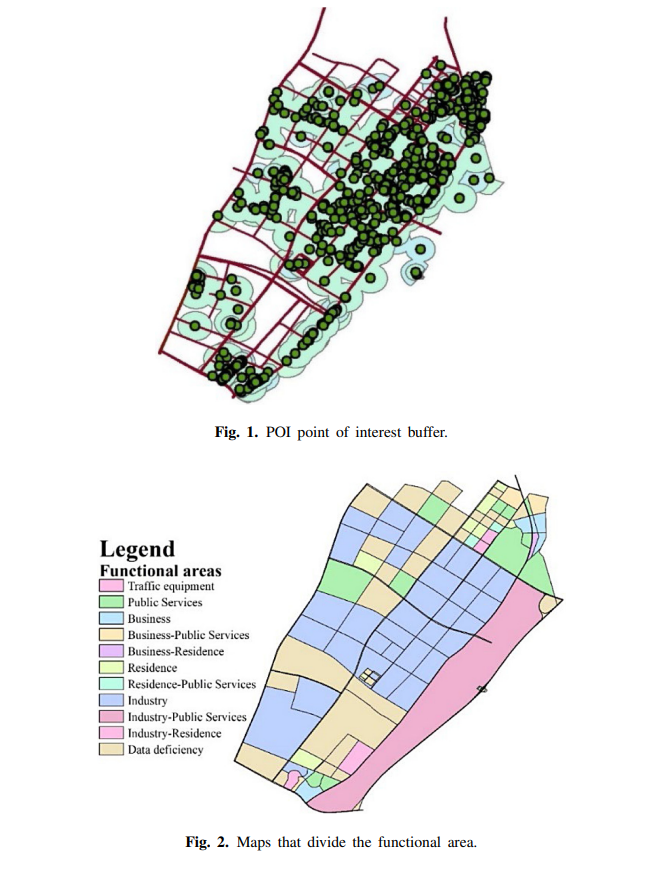

**Temporal-Spatial Analysis**: It examines the temporal patterns of POI usage and spatial distribution to identify areas with high potential demand for charging stations.

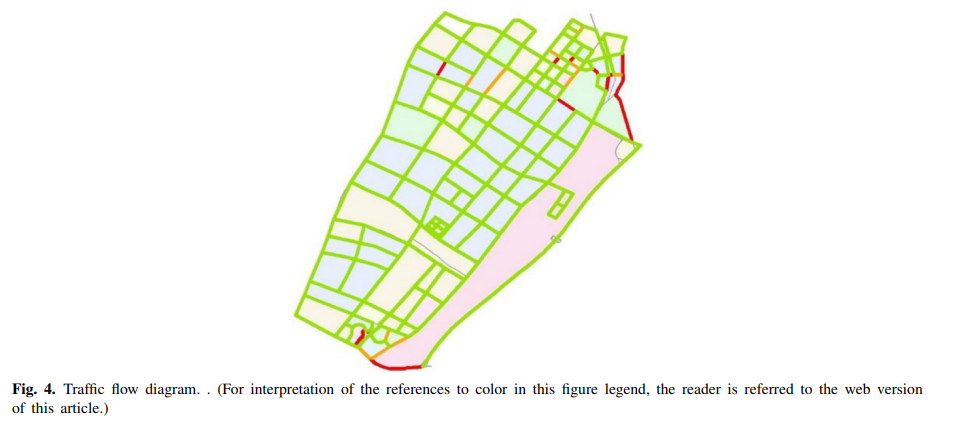

**Users starting positions**

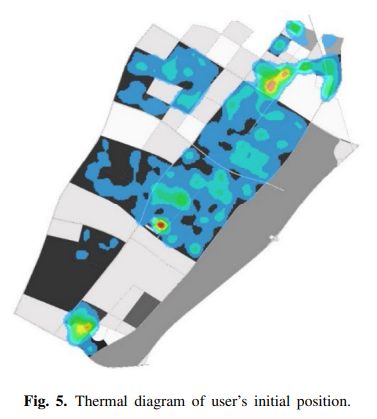

**Final location of fast-charging stations**

- is obtained based on the user’s initial location in the functional area, multi-objective function, and MOSAPSO algorithm

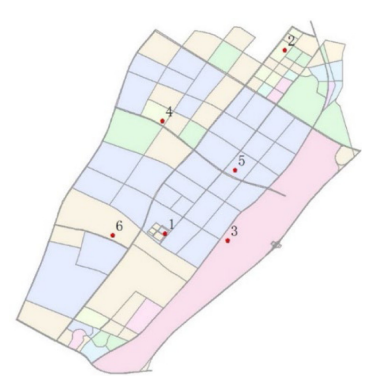

**Conclusion/ Possible Integration for BIFLEX-Project**

- POI Data Integration: Extract POI data from OSM (OpenStreetMap) and align with our MATSim activity locations-
- Functional Classification: Categorize POIs into functional areas to understand the nature of activities in different zones.
- (Temporal Analysis: Analyze the temporal patterns of POI usage to identify peak demand periods for charging.)

[2] [Web Mining to Inform Locations of Charging Stations for Electric Vehicles](https://arxiv.org/pdf/2203.07081)

**Key Contributions and Insights**

Quantitative Assessment of POI Influence: The study introduces a model that quantifies how different types of POIs (e.g., restaurants, shops, transit hubs) impact the usage of nearby EV charging stations. This allows for a nuanced understanding of which POIs are most effective in attracting EV users.

- Spatial Proximity Analysis: By employing a ReLU kernel function, the model determines a "cut-off" distance for each POI type, beyond which its influence on charging station utilization diminishes. This helps in identifying optimal proximities for charger placement relative to various POIs.
- Interpretable Modeling Approach: The model is designed for interpretability, enabling planners to discern the specific contributions of different POIs and spatial factors to charging station usage. This transparency aids in making informed decisions about infrastructure development.
- Empirical Validation with Real-world Data: The methodology is validated using data from approximately 300 charging stations and 4,000 POIs in Amsterdam, demonstrating its practical applicability and effectiveness in a real urban context.

**Application to our MATSim + SUMO Workflow**

Integrating the insights from this paper into your existing simulation framework can enhance the accuracy and relevance of your charging infrastructure planning:

- Activity-Based Demand Modeling: Leverage MATSim's agent-based activity data to identify frequent destinations and overlay this with POI data to pinpoint high-demand areas for charging stations.
- Traffic Flow Analysis: Use SUMO to simulate traffic patterns around identified POIs, assessing congestion levels and potential queuing at proposed charging sites.
- Spatial Optimization: Apply the model's findings on optimal distances between POIs and charging stations to refine the placement strategy within your simulation, ensuring accessibility and convenience for EV users.

**Code**

*Code to generate Population in MATSim (OSMPopulationGenerator.java)*

package org.matsim.project;

import org.matsim.api.core.v01.*;
import org.matsim.api.core.v01.network.Link;
import org.matsim.api.core.v01.population.*;
import org.matsim.core.config.Config;
import org.matsim.core.config.ConfigUtils;
import org.matsim.api.core.v01.population.PopulationWriter;
import org.matsim.core.scenario.ScenarioUtils;
import org.matsim.core.network.io.MatsimNetworkReader;
import org.matsim.api.core.v01.network.Network;


import java.io.File;
import java.util.*;

public class OSMPopulationGenerator {
    public static void main(String[] args) {
        // Paths
        String networkFile = "input-erik/network.xml.gz";
        String outputPopulation = "input-erik/population.xml.gz";

        // Ensure output directory exists
        File outputDirectory = new File("output-erik");
        if (!outputDirectory.exists()) {
            outputDirectory.mkdirs();
        }

        // Load the network into the scenario
        Config config = ConfigUtils.createConfig();
        Scenario scenario = ScenarioUtils.loadScenario(config);
        new MatsimNetworkReader(scenario.getNetwork()).readFile(networkFile);

        // Prepare to generate population
        Network network = scenario.getNetwork();
        Population population = scenario.getPopulation();
        PopulationFactory factory = population.getFactory();
        List<Link> links = new ArrayList<>(network.getLinks().values());

        Random rand = new Random();

        for (int i = 0; i < 1000; i++) {
            Person person = factory.createPerson(Id.createPersonId(i));
            Plan plan = factory.createPlan();

            // Select random links for home and work
            Link homeLink = links.get(rand.nextInt(links.size()));
            Link workLink = links.get(rand.nextInt(links.size()));

            // Create home activity
            Activity home = factory.createActivityFromLinkId("home", homeLink.getId());
            home.setCoord(homeLink.getCoord());
            home.setEndTime(6 * 3600 + rand.nextInt(7200)); // Leave between 6am and 8am
            plan.addActivity(home);

            // Add travel leg
            Leg leg = factory.createLeg("car");
            plan.addLeg(leg);

            // Create work activity
            Activity work = factory.createActivityFromLinkId("work", workLink.getId());
            work.setCoord(workLink.getCoord());
            plan.addActivity(work);

            person.addPlan(plan);
            population.addPerson(person);
        }

        // Write population to file
        new PopulationWriter(population).write(outputPopulation);
        System.out.println("1000-agent population written to " + outputPopulation);
    }
}


*Example Code from plan.xml generated by MATSim*

<!-- ====================================================================== -->

	<person id="0">
		<plan selected="yes">
			<activity type="home" x="7307.485362419502" y="6757.754937541054" end_time="06:29:46" >
			</activity>
			<leg mode="car">
			</leg>
			<activity type="work" x="3419.44685581678" y="9248.682905438669" >
			</activity>
		</plan>

	</person>

<!-- ====================================================================== -->

	<person id="1">
		<plan selected="yes">
			<activity type="home" x="4638.266997495233" y="4685.096846715198" end_time="07:01:56" >
			</activity>
			<leg mode="car">
			</leg>
			<activity type="work" x="1844.731793947354" y="4017.633186992502" >
			</activity>
		</plan>

	</person>

<!-- ====================================================================== -->